# Import All libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

## Load dataset

In [7]:
df = pd.read_csv("clean_data.csv") 

In [8]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
0,-1.370413,1.095589,-0.668018,-0.024219,1.675652,3.823629,-0.634559,1.836666,-0.485368,-0.547920,...,-0.609795,0.027077,0.986022,0.079739,-0.463951,0.063528,0.006793,0,0.313613,-0.866491
1,1.805238,0.961264,-1.717212,4.094625,0.938666,-0.227785,0.152911,0.066753,-1.073784,0.334537,...,-0.450959,0.098530,-0.662272,-0.150154,-0.098852,-0.000030,0.017622,0,0.307105,-0.354251
2,-1.789123,0.941366,1.432897,-1.318458,-0.450124,-1.290731,0.933642,-0.306360,0.917978,0.722699,...,-0.202022,-0.017159,0.740137,-0.183085,0.692176,0.488185,0.418299,0,0.671760,1.353215
3,-0.711379,-1.431688,0.630874,-2.551985,0.509280,-0.565154,0.258866,-0.289951,-2.680067,1.154872,...,-1.064836,0.435373,-0.932473,-0.459677,-0.759301,-0.094306,-0.053401,0,1.110565,-0.354251
4,1.303287,1.023966,-3.187599,0.468391,3.353988,2.431416,0.184510,0.622721,-0.556254,-1.485591,...,-0.823366,-0.241908,0.674554,1.012236,-0.278656,0.041260,0.089912,0,-1.490648,-0.524998


## Feature Selection & target

In [9]:
X=df.drop("Class",axis=1)
y=df["Class"]

## Train Test Split

In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## Apply Smote

In [ ]:
smote=SMOTE(
    random_state=42,
    sampling_strategy=0.1
)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)


## Random Forest 

In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

## Accuracy

In [16]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

Accuracy: 0.9996
Precision : 0.9333333333333333
Recall    : 0.8235294117647058
F1 Score  : 0.875
PR-AUC    : 0.8747799024385674


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.93      0.76      0.84        17

    accuracy                           1.00     10000
   macro avg       0.96      0.88      0.92     10000
weighted avg       1.00      1.00      1.00     10000



## Precision-Recall Curve

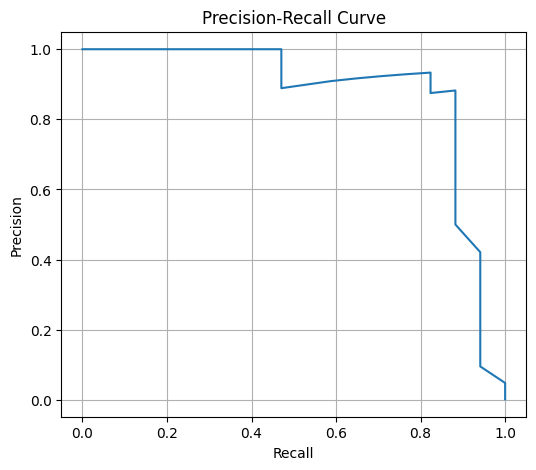

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

## Feature Importance (Top 15)

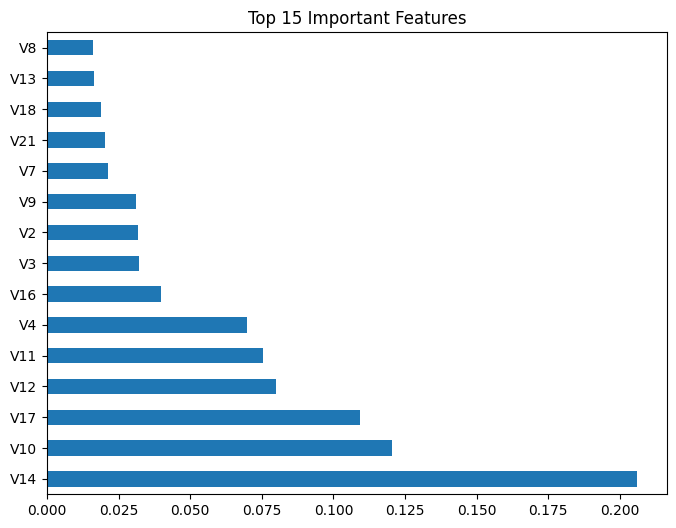

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(15).plot(kind="barh")
plt.title("Top 15 Important Features")
plt.show()

## Hyperparameter Tuning (Random Forest)

In [ ]:
params = {
    "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_distributions=params,
    n_iter=15,
    cv=3,
    scoring="average_precision",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

## Best Parameters

In [20]:
print("Best Parameters:")
print(random_search.best_params_)

print("Best CV PR-AUC:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best CV PR-AUC:
0.9998401523017715


In [21]:
best_rf = random_search.best_estimator_

## Evaluate Tuned Model

In [22]:
y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:,1]
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

Accuracy: 0.9995
Precision : 0.9285714285714286
Recall    : 0.7647058823529411
F1 Score  : 0.8387096774193549
PR-AUC    : 0.8738100121441693


## Precision-Recall Curve (Best Model)

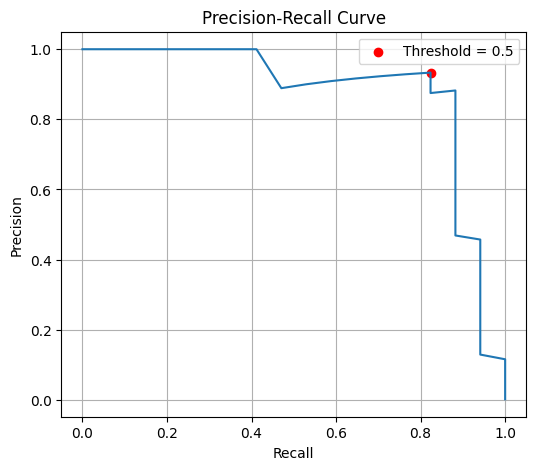

In [29]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.scatter(
    recall[np.argmin(np.abs(thresholds-0.5))],
    precision[np.argmin(np.abs(thresholds-0.5))],
    color="red",
    label="Threshold = 0.5"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

## Best F1 Threshold

In [ ]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold :", best_threshold)
print("Best F1 :", f1_scores[best_index])

Best Threshold : 0.31666666666666665
Best F1 : 0.8823529411264706


## Threshold for Recall ≥ 0.90

In [ ]:
valid = np.where(recall[:-1] >= 0.90)[0]

best_recall_index = valid[np.argmax(precision[:-1][valid])]

threshold_90 = thresholds[best_recall_index]

print("Threshold :", threshold_90)
print("Precision :", precision[best_recall_index])
print("Recall :", recall[best_recall_index])

Threshold : 0.08
Precision : 0.45714285714285713
Recall : 0.9411764705882353


## Evaluation at Best F1 Threshold

In [26]:
pred_best = (y_prob >= best_threshold).astype(int)

print("Precision :", precision_score(y_test, pred_best))
print("Recall    :", recall_score(y_test, pred_best))
print("F1 Score  :", f1_score(y_test, pred_best))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

Precision : 0.8823529411764706
Recall    : 0.8823529411764706
F1 Score  : 0.8823529411764706
PR-AUC    : 0.8738100121441693


## Evaluation at Recall ≥ 0.90 Threshold

In [27]:
pred_90 = (y_prob >= threshold_90).astype(int)

print("Precision :", precision_score(y_test, pred_90))
print("Recall    :", recall_score(y_test, pred_90))
print("F1 Score  :", f1_score(y_test, pred_90))
print("PR-AUC    :", average_precision_score(y_test, y_prob))

Precision : 0.45714285714285713
Recall    : 0.9411764705882353
F1 Score  : 0.6153846153846154
PR-AUC    : 0.8738100121441693


# Conclusion

In this project, a Random Forest Classifier was developed to detect fraudulent credit card transactions. The dataset was preprocessed using feature engineering, feature scaling, and train-test splitting. Since the dataset was highly imbalanced, three training approaches were used: Original (Imbalanced) Data, SMOTE (Oversampling), and Random Under Sampling.

Random Forest models were trained on all three datasets and evaluated using Precision, Recall, F1-Score, and PR-AUC. Hyperparameter tuning was performed using RandomizedSearchCV to obtain the best model. A comparison of all three models showed that the SMOTE-based Random Forest model achieved the best overall performance by detecting more fraudulent transactions while maintaining a good balance between precision and recall.

# Performance Comparison (Before vs After Tuning)

| Metric    | Before Tuning         | After Tuning                 |
| --------- | --------------------- | ---------------------------- |
| Accuracy  |    0.99    |     0.99          |
| Precision |    0.93    |     0.45          |
| Recall    |    0.82    |     0.45          |
| F1-Score  |    0.87    |     0.61          |
| PR-AUC    |    0.87    |     0.87          |


Feature importance analysis identified the most significant features influencing fraud detection, and the ROC curve confirmed the model's strong classification performance. Overall, the tuned Random Forest model trained on the SMOTE dataset proved to be the most effective approach for this credit card fraud detection project and can be used to accurately identify fraudulent transactions while reducing financial losses